# 라이브러리 확인

- 공식문서 : https://opencv.org/

In [3]:
# pip install opencv-python

import cv2
print(cv2.__version__)

4.11.0


# 이미지 확인 테스트

In [4]:
from google.colab import drive
drive.mount("/content/drive")

ModuleNotFoundError: No module named 'google.colab'

In [5]:
url = '/content/drive/MyDrive/Colab Notebooks/2024/한국표준협회/인공지능 신경망과 컴퓨터 비전 이해하기 (9월)/'

- Local PC에서는 구동이 됩니다.

In [1]:
import cv2

img_url = "./images/fruits-2.jpg"

image = cv2.imread(img_url)

# Displaying an image in a window
cv2.imshow('Image', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

- 아래는 Google Colab에서 실행하도록 하는 코드

In [ ]:
from google.colab.patches import cv2_imshow
import cv2
import matplotlib.pyplot as plt

img_url = "/content/drive/MyDrive/Colab Notebooks/2024/한국표준협회/인공지능 신경망과 컴퓨터 비전 이해하기 (9월)/images/fruits-2.jpg"

image = cv2.imread(img_url)
cv2_imshow(image)

- 아래 코드는 Github에 있는 소스코드를 가져와서 사용자 정의 함수로 만든 코드
- 주요 코드 요약
  + 값을 0과 255 사이로 클리핑:
    - 이미지 데이터의 값이 유효한 범위(0-255) 내에 있는지 확인하며, 유효 범위를 벗어난 값을 클리핑하고, 데이터 타입을 uint8로 변환합니다.
  + 컬러 변환 처리
    - `a.ndim == 3` : 이미지가 3차원 배열(컬러 이미지)인지 확인
      - BGRA를 RGBA로 변환 : 이미지가 4채널(BGRA 형식)이면 OpenCV의 cv2.cvtColor를 사용하여 RGBA 형식으로 변환합니다.
      - BGR을 RGB로 변환 : 이미지가 3채널(BGR 형식)이면 BGR(OpenCV의 기본 컬러 형식)에서 RGB(Matplotlib에서 사용하는 표준 형식)로 변환합니다.
    - 이미지가 2차원 배열(`a.ndim == 2`)이면 흑백 이미지로 간주하여 별도의 컬러 변환을 하지 않습니다.
  - Matplotlib의 imshow를 사용하여 이미지를 표시합니다. 이미지가 흑백이면 'gray' 컬러맵을 적용하고, 그렇지 않으면 RGB 이미지를 표시합니다.

In [ ]:
import matplotlib.pyplot as plt

def cv2_imshow(title, a):
    """A replacement for cv2.imshow() for use in Jupyter notebooks using Matplotlib.

    Args:
        title: str, optional. The title of the image to be displayed.
        a : np.ndarray. shape (N, M) or (N, M, 1) is an NxM grayscale image.
            shape (N, M, 3) is an NxM BGR color image. shape (N, M, 4) is an NxM BGRA color image.
    """
    a = a.clip(0, 255).astype('uint8')
    # cv2 stores colors as BGR; convert to RGB
    if a.ndim == 3:
        if a.shape[2] == 4:
            a = cv2.cvtColor(a, cv2.COLOR_BGRA2RGBA)
        else:
            a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
    elif a.ndim == 2:
        # If it's grayscale, don't convert to RGB
        pass

    plt.imshow(a, cmap='gray' if a.ndim == 2 else None)
    if title is not None:
        plt.title(title)
    plt.axis('off')  # Hide axes for better display
    plt.show()

In [ ]:
image = cv2.imread(img_url)
cv2_imshow("hello", image)

# 화소처리

## 영상 화소 접근

### 화소(행렬 원소) 접근
- 행렬의 모든 원소를 순회하여 원소값을 2배로 변경하는 소스

In [8]:
# from google.colab.patches import cv2_imshow
import cv2
import numpy as np

def mat_access1(mat):
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            k = mat[i, j]  # 원소 접근 - mat1[i][j] 방식도 가능
            mat[i, j] = k * 2  # 원소 할당

def mat_access2(mat):
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            k = mat.item(i, j)  # 원소 접근
            mat.itemset((i, j), k * 2)  # 원소 할당

mat1 = np.arange(10).reshape(2, 5)
mat2 = np.arange(10).reshape(2, 5)

print("원소 처리 전: \n%s\n" % mat1)
mat_access1(mat1)
print("원소 처리 후: \n%s\n" % mat1)

print("원소 처리 전: \n%s\n" % mat2)
mat_access2(mat2)
print("원소 처리 후: \n%s" % mat2)

원소 처리 전: 
[[0 1 2 3 4]
 [5 6 7 8 9]]

원소 처리 후: 
[[ 0  2  4  6  8]
 [10 12 14 16 18]]

원소 처리 전: 
[[0 1 2 3 4]
 [5 6 7 8 9]]

원소 처리 후: 
[[ 0  2  4  6  8]
 [10 12 14 16 18]]


- 행렬을 처리하여 영상의 반전을 수행하는 다양한 방법들을 함수로 만들고 각 방법의 수행속도 계산

[방법 1] 직접 접근 방식 수행시간 : 642.98 ms
[방법 2] item() 함수 방식 수행시간 : 102.79 ms
[방법 3] 룩업 테이블 방식 수행시간 : 1.09 ms
[방법 4] OpenCV 함수 방식 수행시간 : 0.15 ms
[방법 5] ndarray 연산 방식 수행시간 : 0.08 ms


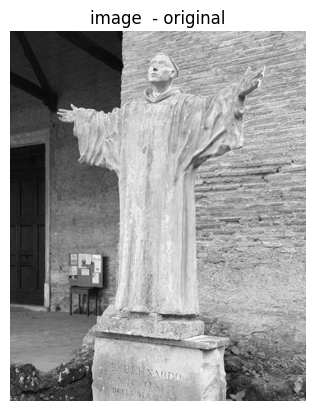

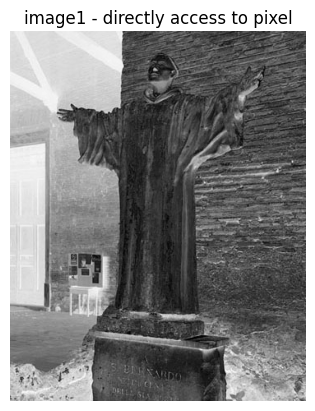

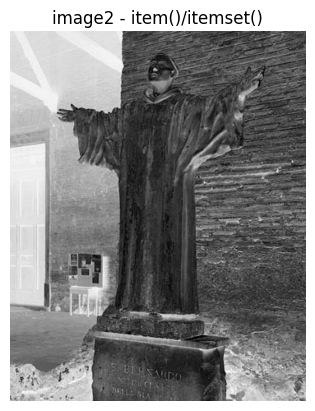

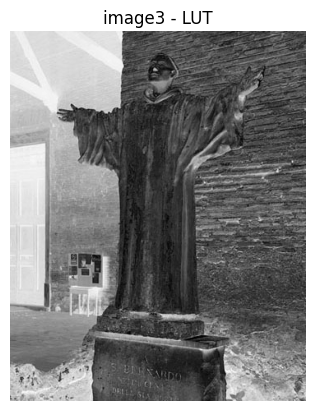

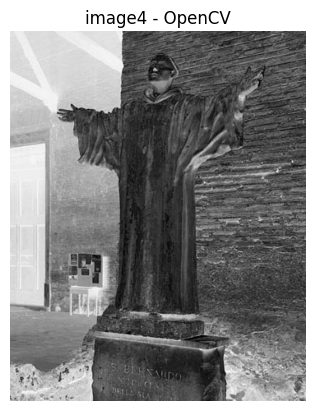

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


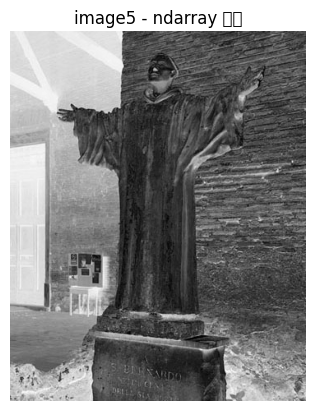

In [12]:
import numpy as np, cv2, time

def pixel_access1(image):
    image1 = np.zeros(image.shape[:2], image.dtype)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            pixel = image[i,j]                  # 화소 접근
            image1[i, j] =  255 - pixel            # 화소 할당
    return image1

def pixel_access2(image):
    image2 = np.zeros(image.shape[:2], image.dtype)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            pixel = image.item(i, j)  # 화소 접근
            image2.itemset((i, j),  255 - pixel)  # 화소 할당
    return image2

def pixel_access3(image):
    lut = [255 - i for i in range(256)]  # 룩업테이블 생성
    lut = np.array(lut, np.uint8)
    image3 = lut[image]
    return image3

def pixel_access4(image):
    image4 = cv2.subtract(255, image)
    return image4

def pixel_access5(image):
    image5 = 255 - image
    return image5

image = cv2.imread(url + "images/bright.jpg", cv2.IMREAD_GRAYSCALE)
if image is None: raise Exception("영상 파일 읽기 오류 발생")

# 수행시간 체크
def time_check(func, msg):
    start_time = time.perf_counter()
    ret_img = func(image)
    elapsed = (time.perf_counter() - start_time) * 1000
    print(msg, "수행시간 : %.2f ms" % elapsed)
    return ret_img

image1 = time_check(pixel_access1, "[방법 1] 직접 접근 방식")
image2 = time_check(pixel_access2, "[방법 2] item() 함수 방식")
image3 = time_check(pixel_access3, "[방법 3] 룩업 테이블 방식")
image4 = time_check(pixel_access4, "[방법 4] OpenCV 함수 방식")
image5 = time_check(pixel_access5, "[방법 5] ndarray 연산 방식")

# 결과 영상 보기
cv2_imshow("image  - original", image)
cv2_imshow("image1 - directly access to pixel", image1)
cv2_imshow("image2 - item()/itemset()", image2)
cv2_imshow("image3 - LUT", image3)
cv2_imshow("image4 - OpenCV", image4)
cv2_imshow("image5 - ndarray 방식", image5)

- 결론 : 행렬 화소에 직접 접근하는 것보다 OpenCV에서 지원하는 함수 사용할 것

## 화소 밝기 변환

### 그레이 스케일(명암도) 영상
- 하나의 화소값은 0~255의 값을 가짐
- 0은 검은색을, 255는 흰색을 의미

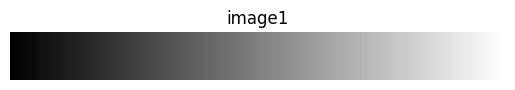

In [ ]:
image1 = np.zeros((50, 512), np.uint8)         # 50 x 512 영상 생성
image2 = np.zeros((50, 512), np.uint8)

rows, cols = image1.shape[:2]

for i in range(rows):                           # 행렬 전체 조회
    for j in range(cols):
        image1[i, j]= j // 2                # 화소값 점진적 증가
        image2[i, j]= j // 20 * 10          # 계단 현상 증가

cv2_imshow("image1", image1)

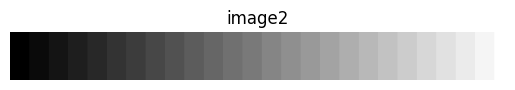

In [ ]:
cv2_imshow("image2", image2)

### 영상의 화소 표현
- 파일을 읽어 들여서 영상의 특정 부분의 화소 확인

[roi_img] =
  56  51  59  66  84 104 154 206 220 208 203 207 205 204 204
  75  57  53  53  72  71 100 152 195 214 212 201 209 207 205
  88  76  65  53  51  60  73  96 143 200 219 200 206 204 202
  91  92  80  63  53  59  59  61  89 144 195 222 205 200 205
  89  94  90  82  63  54  51  56  65  92 149 203 223 209 196
  89  91  90  89  84  64  54  55  51  56  94 140 208 223 203
  91  86  84  85  97  86  72  59  50  53  66  81 148 211 216
  92  86  85  88  92  95  88  70  55  53  59  64  89 155 211
  88  85  86  90  87  87  89  86  72  56  50  53  59  88 175
  87  85  86  88  87  84  86  90  86  70  53  44  51  56 111


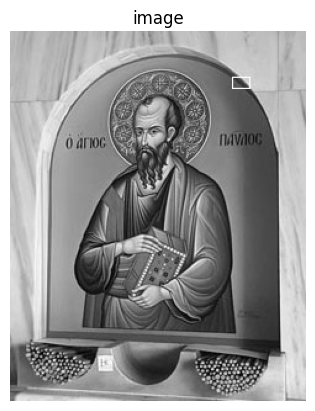

In [ ]:
url = '/content/drive/MyDrive/Colab Notebooks/2024/한국표준협회/인공지능 신경망과 컴퓨터 비전 이해하기 (9월)/'
image = cv2.imread(url + "images/pixel.jpg", cv2.IMREAD_GRAYSCALE) # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류 발생")

(x,y),(w,h) = (180, 37), (15, 10)                   # 좌표는 x, y
roi_img = image[y:y+h, x:x+w]                   # 행렬 접근은 y, x

# print(“[roi_img] =\n”, roi_img) # 행렬 원소 바로 출력 가능
print("[roi_img] =")
for row in roi_img:
    for p in row:
        print("%4d" % p, end="")       # 행렬 원 하나 출력
    print()

cv2.rectangle(image, (x,y, w,h), 255, 1)
cv2_imshow("image", image)

### 영상 밝기의 가감 연산
- OpenCV의 Saturation 방식
- NumPy의 Module 방식의 차이 이해

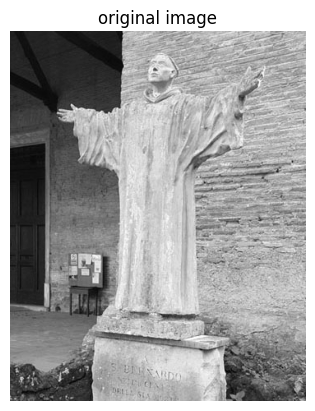

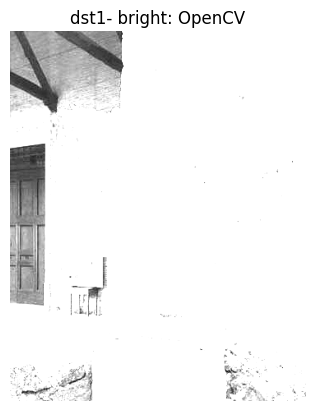

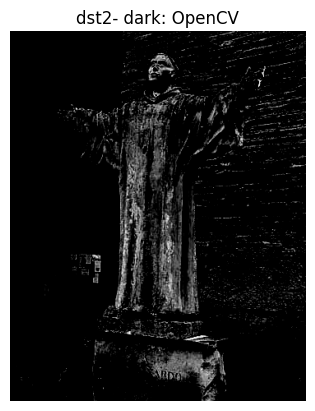

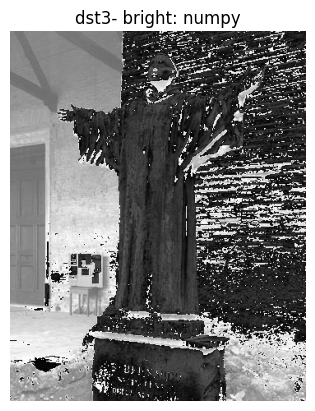

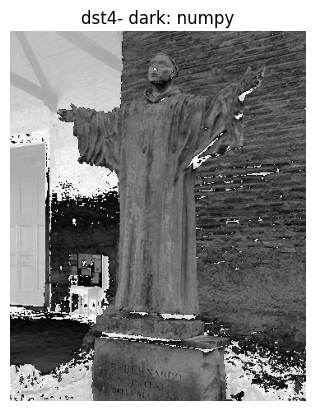

In [13]:
import cv2

image = cv2.imread(url + "images/bright.jpg", cv2.IMREAD_GRAYSCALE)    # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류")

# OpenCV 함수 이용
dst1 = cv2.add(image, 200)                  # 영상 밝게 saturation 방식
dst2 = cv2.subtract(image, 200)             # 영상 어둡게

# numpy array 이용
dst3 = image + 100                          # 영상 밝게 modulo 방식
dst4 = image - 100                          # 영상 어둡게

cv2_imshow("original image", image)
cv2_imshow("dst1- bright: OpenCV", dst1)
cv2_imshow("dst2- dark: OpenCV", dst2)
cv2_imshow("dst3- bright: numpy", dst3)
cv2_imshow("dst4- dark: numpy", dst4);

### 행렬 덧셈 및 곱셈을 이용한 영상 합성

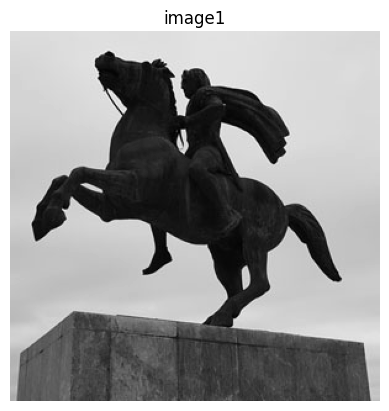

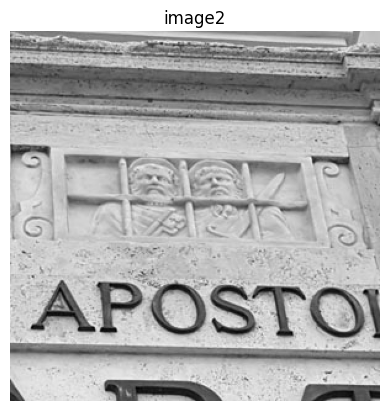

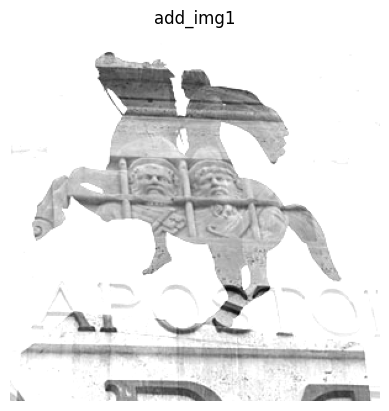

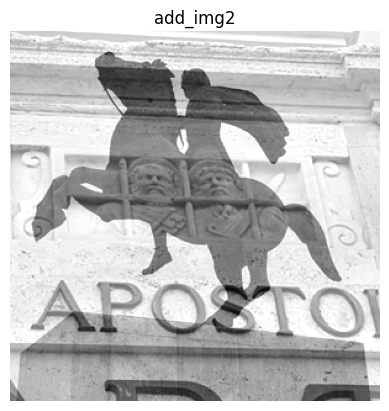

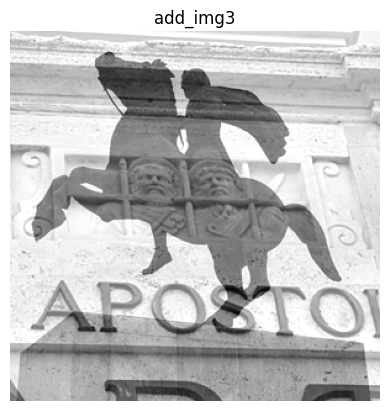

In [15]:
import numpy as np, cv2

image1 = cv2.imread(url + "images/add1.jpg", cv2.IMREAD_GRAYSCALE)   # 영상 읽기
image2 = cv2.imread(url + "images/add2.jpg", cv2.IMREAD_GRAYSCALE)
if image1 is None or image2 is None: raise Exception("영상 파일 읽기 오류 발생")

# 영상 합성
alpha, beta = 0.6, 0.7                                        # 곱샘 비율
add_img1 = cv2.add(image1 , image2)                            # 두 영상 단순 더하기
add_img2 = cv2.add(image1 * alpha , image2 * beta)             # 두영상 비율에 따른 더하기
add_img2 = np.clip(add_img2, 0, 255).astype("uint8")           # saturation 처리
add_img3 = cv2.addWeighted(image1, alpha, image2, beta, 0)     # 두영상 비율에 따른 더하기

titles = ['image1','image2','add_img1','add_img2','add_img3']
for t in titles:
  cv2_imshow(t, eval(t))

### 명암 대비
- 명암 대비(Contrast)는 상이한 두 가지 색(밝기)이 경계에서 서로 영향을 미쳐 그 차이가 강조되어 나타나는 현상을 말함

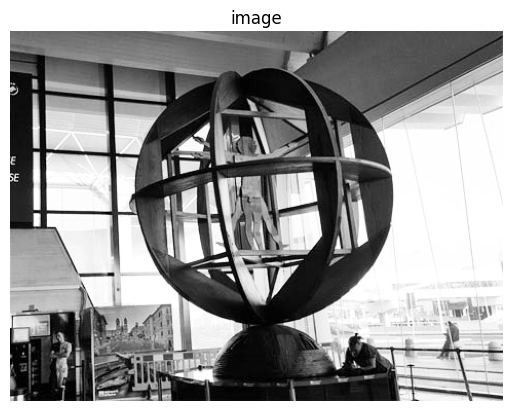

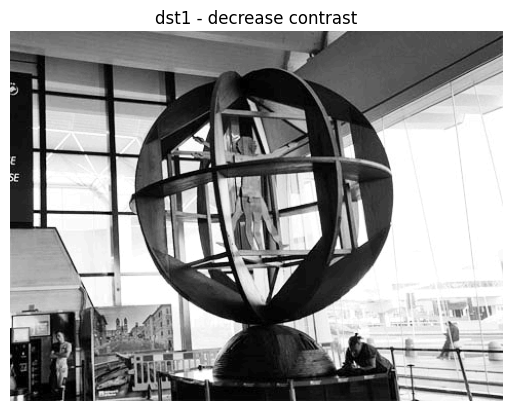

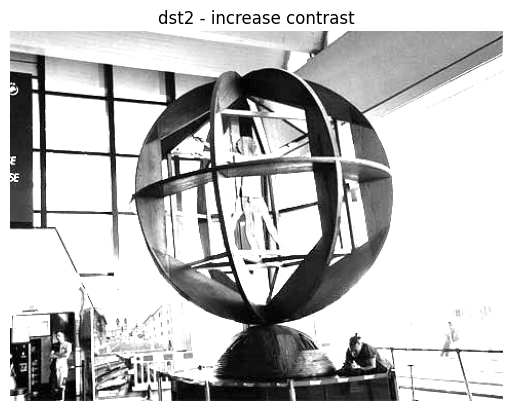

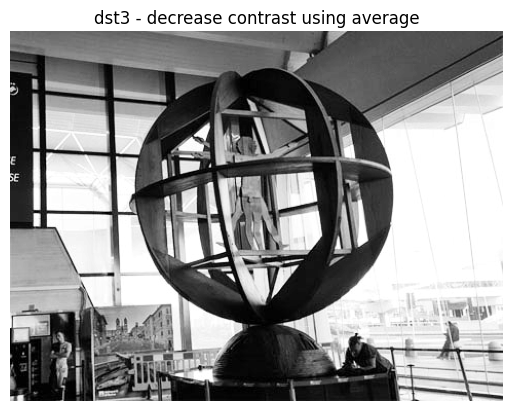

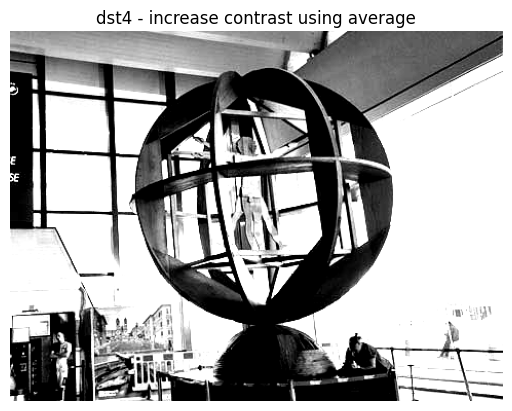

True

In [16]:
import numpy as np, cv2

image = cv2.imread(url + "images/contrast.jpg", cv2.IMREAD_GRAYSCALE)  # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류 발생")

noimage = np.zeros(image.shape[:2], image.dtype)        # 더미 영상
avg = cv2.mean(image)[0]/2.0                            # 영상 화소 평균의 절반

dst1 = cv2.scaleAdd(image, 0.2, noimage) + 20               # 영상대비 감소
dst2 = cv2.scaleAdd(image, 2.0, noimage)                # 영상대비 증가
dst3 = cv2.addWeighted(image, 0.5, noimage, 0, avg)     # 명암대비 감소
dst4 = cv2.addWeighted(image, 2.0, noimage, 0,-avg)     # 명암대비 증가

# 영상 띄우기
cv2_imshow("image", image)
cv2_imshow("dst1 - decrease contrast", dst1)
cv2_imshow("dst2 - increase contrast", dst2)
cv2_imshow("dst3 - decrease contrast using average", dst3)
cv2_imshow("dst4 - increase contrast using average", dst4)

cv2.imwrite("dst.jpg",dst1)

## 히스토그램
- 관측값의 개수를 겹치지 않는 다양한 계급으로 표시하는 것

In [17]:
# -*- coding: utf-8 -*-
import numpy as np
import cv2, time

def draw_histo(hist, shape=(200, 256)):
    hist_img = np.full( shape, 255, np.uint8)
    cv2.normalize(hist, hist, 0, shape[0], cv2.NORM_MINMAX)
    gap = hist_img.shape[1]/hist.shape[0]             # 한 계급 너비

    for i, h in enumerate(hist):
        x = int(round(i * gap))                         # 막대 사각형 시작 x 좌표
        w = int(round(gap))
        roi = (x, 0, w, int(h))
        cv2.rectangle(hist_img, roi, 0, cv2.FILLED)
    return cv2.flip(hist_img, 0)                        # 영상 상하 뒤집기 후 반환


def make_palate(rows):
    hue = [round(i * 180 / rows) for i in range(rows)]  # hue 값 리스트 계산
    hsv = [[(h, 255, 255)] for h in hue]                # (hue, 255,255) 화소값 계산
    hsv = np.array(hsv, np.uint8)                       # numpy 행렬의 uint8형 변환
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)         # HSV 컬러 -> BGR 컬러

# 색상으로 히스토그램 그리기
def draw_histo_hue(hist, shape=(200, 256,3)):
    hsv_palate = make_palate(hist.shape[0])                      # 색상 팔레트 생성
    hist_img = np.full(shape, 255, np.uint8)
    cv2.normalize(hist, hist, 0, shape[0], cv2.NORM_MINMAX)    # 정규화
    gap = hist_img.shape[1] / hist.shape[0]  # 한 계급 크기

    for i, h in enumerate(hist):
        x, w = int(round(i * gap)), int(round(gap))
        if h > 0:
            color = tuple(map(int, hsv_palate[i][0]))                    # 정수형 튜플로 변환
            cv2.rectangle(hist_img, (x,0, w,int(h) ), color , cv2.FILLED) # 팔레트 색으로 그리기

    return cv2.flip(hist_img, 0)

### 영상 히스토그램 계산
- 0~255까지의 모든 화소값에 대해 출현 빈도수를 누적하여 배열에 저장

사용자 정의 함수: 
 [  97.  247.  563. 1001. 1401. 1575. 1724. 1951. 2853. 3939. 3250. 2549.
 2467. 2507. 2402. 2418. 2727. 3203. 3410. 3161. 2985. 2590. 3384. 4312.
 4764. 3489. 2802. 2238. 1127.  628.  199.   37.]


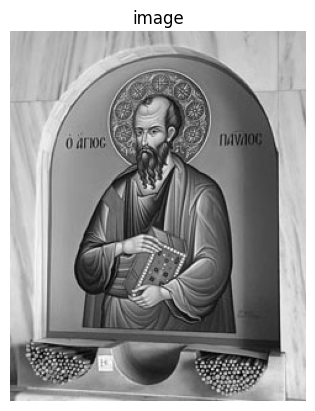

In [18]:
import numpy as np, cv2

def calc_histo(image, hsize, ranges=[0, 256]):  # 행렬 원소의 1차원 히스토그램 계산
    hist = np.zeros((hsize, 1), np.float32)  # 히스토그램 누적 행렬
    gap = ranges[1]/hsize  # 계급 간격

    for i in (image/gap).flat:
        hist[int(i)] += 1
    return hist

image = cv2.imread(url + "images/pixel.jpg", cv2.IMREAD_GRAYSCALE)  # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류 발생")

hsize, ranges = [32], [0, 256]  # 히스토그램 간격수, 값 범위
hist = calc_histo(image, hsize[0], ranges)  # 사용자 정의 히스토그램 계산

print("사용자 정의 함수: \n", hist.flatten())  # 행렬을 벡터로 변환하여 출력
cv2_imshow("image", image)

### OpenCV 함수 활용 계산
- cv2.calcHist : https://docs.opencv.org/4.10.0/d6/dc7/group__imgproc__hist.html#ga4b2b5fd75503ff9e6844cc4dcdaed35d

User 함수: 
 [  97.  247.  563. 1001. 1401. 1575. 1724. 1951. 2853. 3939. 3250. 2549.
 2467. 2507. 2402. 2418. 2727. 3203. 3410. 3161. 2985. 2590. 3384. 4312.
 4764. 3489. 2802. 2238. 1127.  628.  199.   37.]
OpenCV 함수: 
 [  97.  247.  563. 1001. 1401. 1575. 1724. 1951. 2853. 3939. 3250. 2549.
 2467. 2507. 2402. 2418. 2727. 3203. 3410. 3161. 2985. 2590. 3384. 4312.
 4764. 3489. 2802. 2238. 1127.  628.  199.   37.]
numpy 함수: 
 [  97.  247.  563. 1001. 1401. 1575. 1724. 1951. 2853. 3939. 3250. 2549.
 2467. 2507. 2402. 2418. 2727. 3203. 3410. 3161. 2985. 2590. 3384. 4312.
 4764. 3489. 2802. 2238. 1127.  628.  199.   37.]


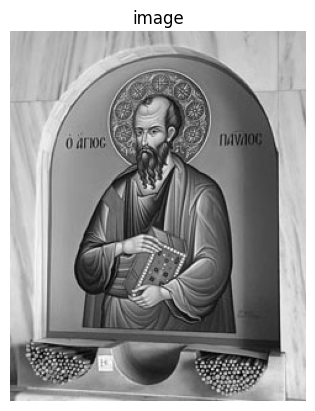

In [19]:
import numpy as np, cv2

def calc_histo(image, hsize, ranges=[0, 256]):  # 행렬 원소의 1차원 히스토그램 계산
    hist = np.zeros((hsize, 1), np.float32)  # 히스토그램 누적 행렬
    gap = ranges[1]/hsize  # 계급 간격

    for i in (image/gap).flat:
        hist[int(i)] += 1
    return hist


image = cv2.imread(url + "images/pixel.jpg", cv2.IMREAD_GRAYSCALE) # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류 발생")

hsize, ranges = [32], [0, 256]                  # 히스토그램 간격수, 값 범위
gap = ranges[1]/hsize[0]
ranges_gap  = np.arange(0, ranges[1]+1, gap)
hist1 = calc_histo(image, hsize[0], ranges)  # User 함수
hist2 = cv2.calcHist([image], [0], None, hsize, ranges)  # OpenCV 함수
hist3, bins = np.histogram(image, ranges_gap )

print("User 함수: \n", hist1.flatten())                  # 행렬을 벡터로 변환하여 출력
print("OpenCV 함수: \n", hist2.flatten())                # 행렬을 벡터로 변환하여 출력
print("numpy 함수: \n", hist3.astype(float))             # 행렬을 벡터로 변환하여 출력

cv2_imshow("image", image)

### OpenCV 함수 활용 히스토그램 그래프 그리기

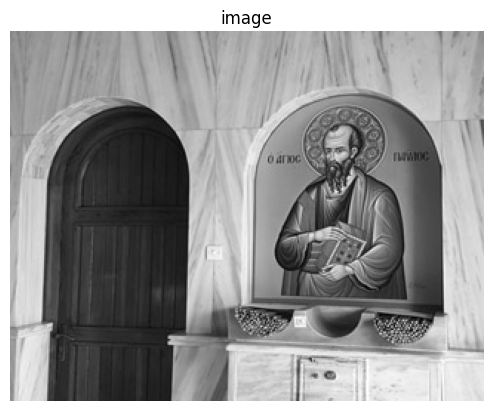

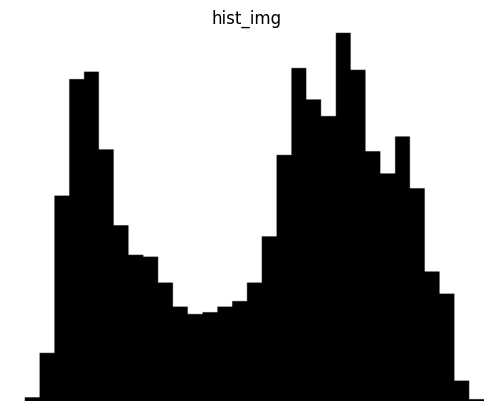

In [20]:
import numpy as np, cv2

def draw_histo(hist, shape=(200, 256)):
    hist_img = np.full( shape, 255, np.uint8)
    cv2.normalize(hist, hist, 0, shape[0], cv2.NORM_MINMAX)
    gap = hist_img.shape[1]/hist.shape[0]             # 한 계급 너비

    for i, h in enumerate(hist.flat):
        x = int(round(i * gap))                         # 막대 사각형 시작 x 좌표
        w = int(round(gap))
        cv2.rectangle(hist_img, (x, 0, w, int(h)), 0, cv2.FILLED)
    return   cv2.flip(hist_img, 0)                        # 영상 상하 뒤집기 후 반환

image = cv2.imread(url + "images/draw_hist.jpg", cv2.IMREAD_GRAYSCALE)  # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류")

hist = cv2.calcHist([image], [0], None, [32], [0, 256])
hist_img = draw_histo(hist)

cv2_imshow("image", image)
cv2_imshow("hist_img", hist_img)

### 색상 히스토그램 그리기

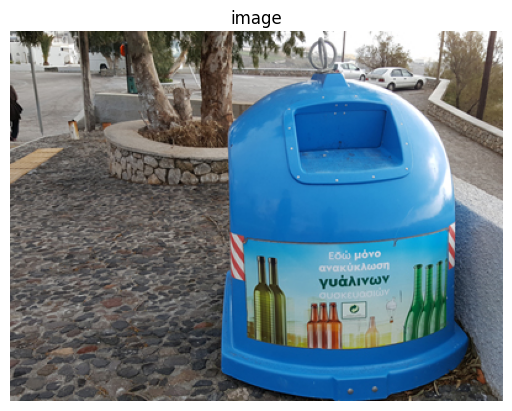

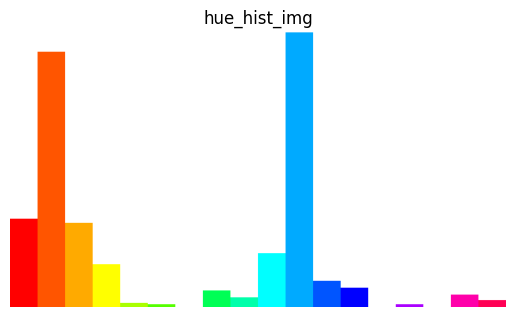

In [21]:
import numpy as np, cv2

def make_palette(rows):
    # 리스트 생성 방식
    hue = np.arange(0, rows ) / rows * 180
    hsv = [[(h, 255, 255)] for h in hue]                # (hue, 255,255) 화소값 계산
    hsv = np.array(hsv, np.uint8)                       # numpy 행렬의 uint8형 변환

    # ndarray 생성 방식
    # hsv = np.full((rows, 1, 3), 255, np.uint8)
    # hsv[:, 0, 0] = np.arange(0, rows ) / rows * 180
    # 반복문 방식
    # hsv = np.full((rows, 1, 3), 255, np.uint8)
    # for i in range(0, rows):                           # 행수만큼 반복
    #     hsv[i, 0, 0] = round(i / rows * 180 )         # HSV 컬러 지정
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)         # HSV 컬러 -> BGR 컬러

def draw_histo_hue(hist, shape=(200, 256,3)):
    hsv_palate = make_palette(hist.shape[0])                      # 색상 팔레트 생성
    hist_img = np.full(shape, 255, np.uint8)
    cv2.normalize(hist, hist, 0, shape[0], cv2.NORM_MINMAX)    # 정규화

    gap = hist_img.shape[1] / hist.shape[0]  # 한 계급 크기
    for i, h in enumerate(hist.flat):
        x, w = int(round(i * gap)), int(round(gap))
        color = tuple(map(int, hsv_palate[i][0]))                    # 정수형 튜플로 변환
        cv2.rectangle(hist_img, (x,0,w,int(h)), color , cv2.FILLED) # 팔레트 색으로 그리기
    return cv2.flip(hist_img, 0)

image = cv2.imread(url + "images/hue_hist.jpg", cv2.IMREAD_COLOR)  # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류")

hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)   # BGR 컬러 -> HSV 컬러
hue_hist = cv2.calcHist( [hsv_img], [0], None, [18], [0,180])       # Hue 채널 히스토그램 계산
hue_hist_img = draw_histo_hue(hue_hist, (200, 360, 3)) # 히스토그램 그래프

cv2_imshow("image", image)
cv2_imshow("hue_hist_img", hue_hist_img)

### 히스토그램 스트레칭
- 영상이 보기에 선명하고 깨끗해 보이려면 어두운 부분에서 밝은 부분까지 고루 분되어야 함
- 히스토그램의 분포가 바뀐다는 것은 영상 내의 화소값의 분포가 바뀐다는 것을 의미함

high_value =  180.0
low_value =  52.0


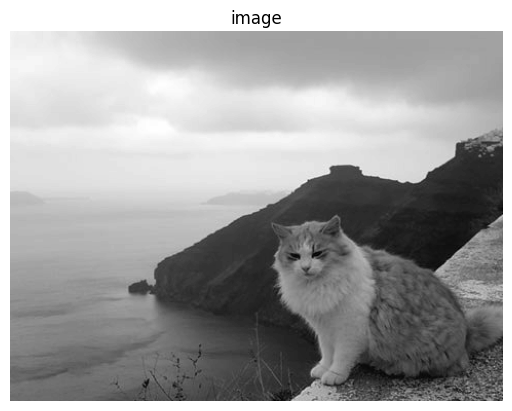

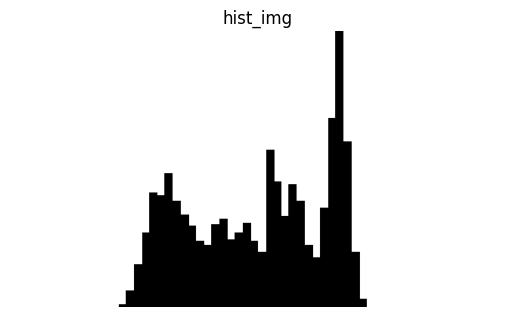

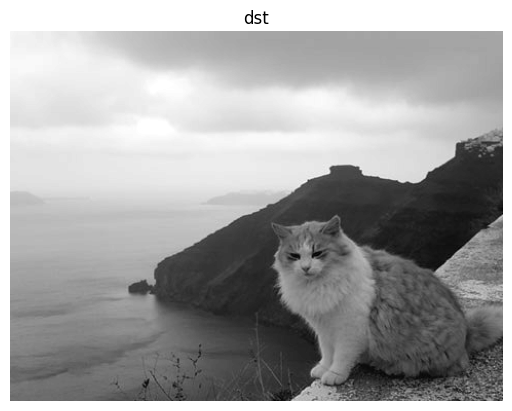

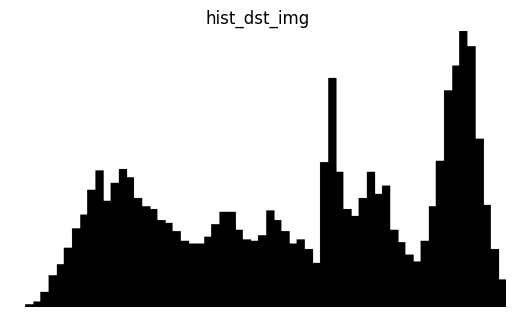

-1

In [22]:
import numpy as np, cv2

def search_value_idx(hist, bias = 0):
    for i in range(hist.shape[0]):
        idx = np.abs(bias - i)                     # 검색 위치 (처음 또는 마지막)
        if hist[idx] > 0:  return idx                             # 위치 반환
    return -1                                      # 대상 없으면 반환

image = cv2.imread(url + "images/hist_stretch.jpg", cv2.IMREAD_GRAYSCALE)   # 영상읽기
if image is None: raise Exception("영상 파일 읽기 오류")

bsize, ranges = [64], [0,256]                        # 계급 개수 및 화소 범위
hist = cv2.calcHist([image], [0], None, bsize, ranges)

bin_width  = ranges[1]/bsize[0]                      # 계급 너비
high = search_value_idx(hist, bsize[0] - 1) * bin_width
low  = search_value_idx(hist, 0) * bin_width

idx = np.arange(0, 256)
idx = (idx - low) * 255/(high-low)	# 수식 적용하여 인덱스 생성
idx[0:int(low)] = 0
idx[int(high+1):] = 255

dst = cv2.LUT(image, idx.astype('uint8'))
# dst = idx.astype('uint8')[image]                #

## 룩업 테이블 사용하지 않고 직접 구현
# dst = np.zeros(image.shape, dtype=image.dtype)
# for i in range(dst.shape[0]):
#     for j in range(dst.shape[1]):
#         dst[i,j] = idx[image[i,j]]

hist_dst = cv2.calcHist([dst], [0], None, bsize, ranges)  # 결과 영상 히스토그램 재계산
hist_img = draw_histo(hist, (200,360))          # 원본 영상 히스토그램 그리기
hist_dst_img = draw_histo(hist_dst,(200,360))  # 결과 영상 히스토그램 그리기

print("high_value = ", high)
print("low_value = " , low)
cv2_imshow("image", image);         cv2_imshow("hist_img", hist_img)
cv2_imshow("dst", dst);             cv2_imshow("hist_dst_img", hist_dst_img)
cv2.waitKey(0)

### 히스토그램 평활화
- 평활화(Equalization)
  + 인간의 눈은 영상의 밝기의 크기보다 대비가 증가할 때 인지도가 향상됨

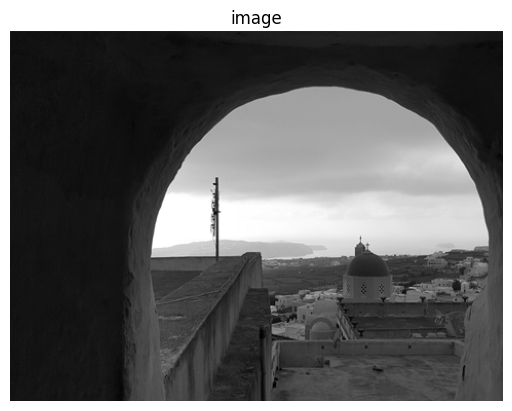

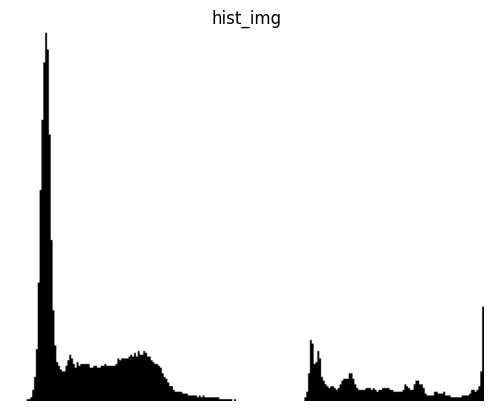

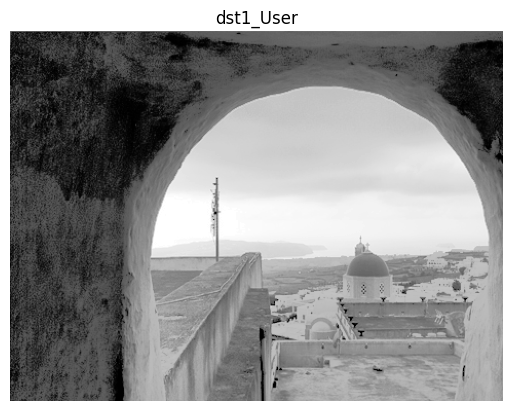

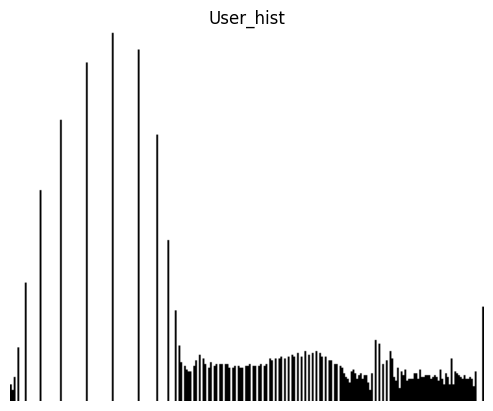

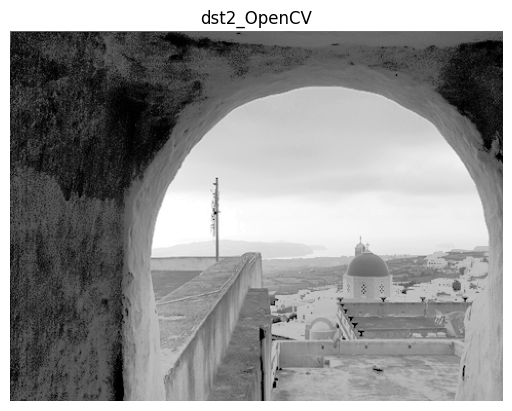

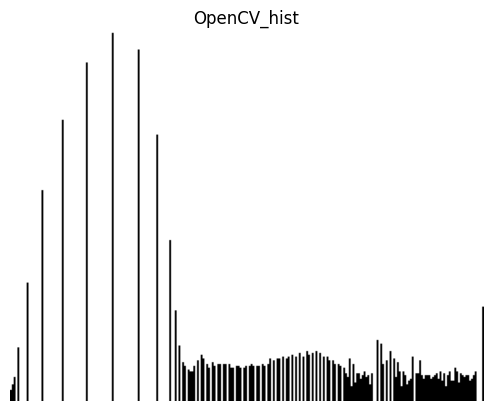

In [23]:
import numpy as np, cv2

image = cv2.imread(url + "images/equalize.jpg", cv2.IMREAD_GRAYSCALE) # 영상 읽기
if image is None: raise Exception("영상 파일 읽기 오류")

bins, ranges = [256], [0, 256]
hist = cv2.calcHist([image], [0], None, bins, ranges)    # 히스토그램 계산

# 히스토그램 누적합 계산
accum_hist = np.zeros(hist.shape[:2], np.float32)
accum_hist[0] = hist[0]
for i in range(1, hist.shape[0]):
    accum_hist[i] = accum_hist[i - 1] + hist[i]

accum_hist = (accum_hist / sum(hist)) * 255                 # 누적합의 정규화
dst1 = [[accum_hist[val] for val in row] for row in image] # 화소값 할당
dst1 = np.array(dst1, np.uint8)

# numpy 함수 사용
#accum_hist = np.cumsum(hist)                      # 누적합 계산
#cv2.normalize(accum_hist, accum_hist, 0, 255, cv2.NORM_MINMAX)  # 정규화

dst1 = cv2.LUT(image, accum_hist.astype("uint8"))  #룩업 테이블로 화소값할당
# dit1 = image[accum_hist.astype('uint8')]         # 파이썬 방식 록업테이블
dst2 = cv2.equalizeHist(image)                # OpenCV 히스토그램 평활화

hist1 = cv2.calcHist([dst1], [0], None, bins, ranges)   # 히스토그램 계산
hist2 = cv2.calcHist([dst2], [0], None, bins, ranges)   # 히스토그램 계산
hist_img = draw_histo(hist)
hist_img1 = draw_histo(hist1)
hist_img2 = draw_histo(hist2)

cv2_imshow("image", image);             cv2_imshow("hist_img", hist_img)
cv2_imshow("dst1_User", dst1);          cv2_imshow("User_hist", hist_img1)
cv2_imshow("dst2_OpenCV", dst2);        cv2_imshow("OpenCV_hist", hist_img2)

## 컬러 공간 변환

### BGR => CMY 변환

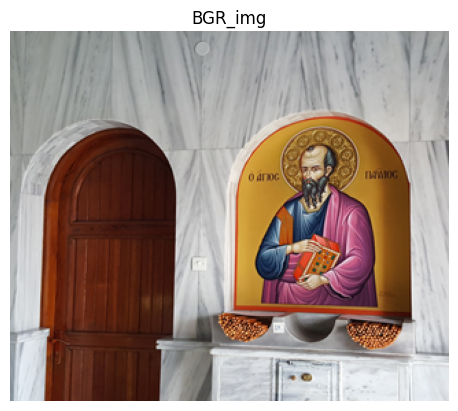

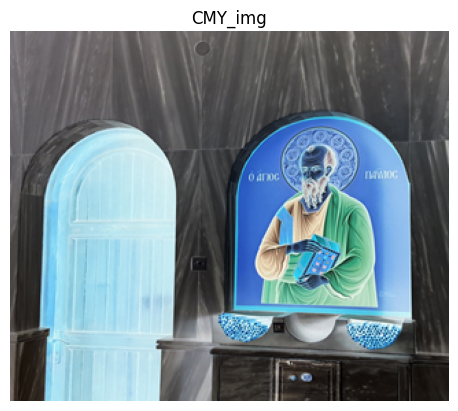

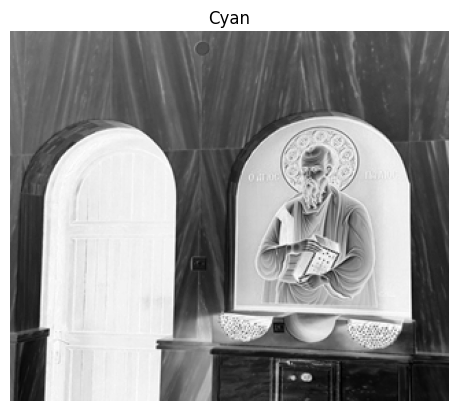

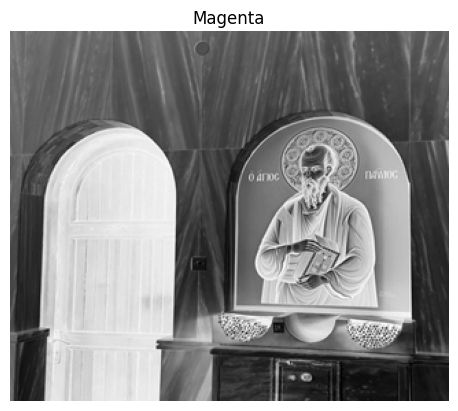

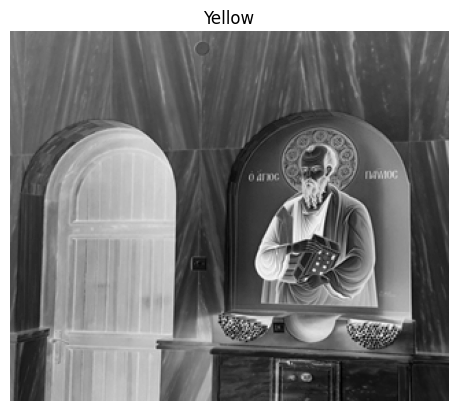

[None, None, None, None, None]

In [24]:
import numpy as np, cv2

BGR_img = cv2.imread(url + "images/color_model.jpg", cv2.IMREAD_COLOR) # 컬러 영상 읽기
if BGR_img is None: raise Exception("영상 파일 읽기 오류")

white = np.array([255, 255, 255], np.uint8)
CMY_img = white - BGR_img
Cyan, Magenta, Yellow = cv2.split(CMY_img) # 채널 분리

titles = ['BGR_img','CMY_img','Cyan','Magenta','Yellow']
[cv2_imshow(t, eval(t)) for t in titles]

### BGR => CMYK 변환

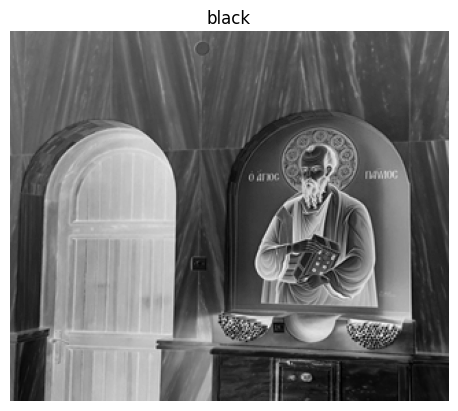

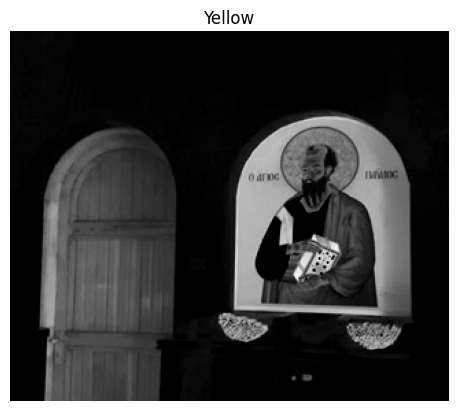

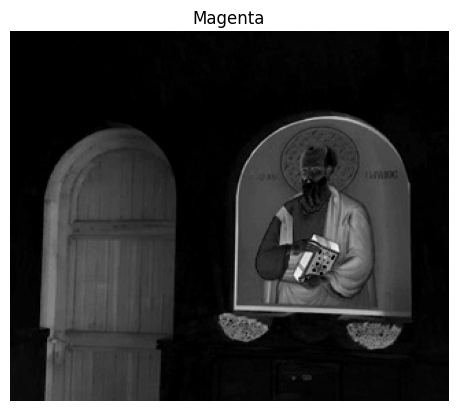

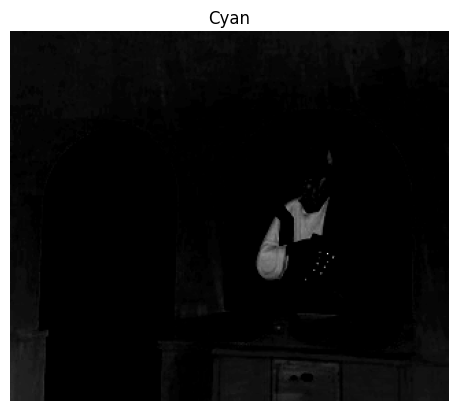

[None, None, None, None]

In [25]:
import numpy as np, cv2

BGR_img = cv2.imread(url + "images/color_model.jpg", cv2.IMREAD_COLOR) # 컬러 영상 읽기
if BGR_img is None: raise Exception("영상 파일 읽기 오류")

white = np.array([255, 255, 255], np.uint8)
CMY_img = white - BGR_img
CMY = cv2.split(CMY_img) # 채널 분리

black = cv2.min(CMY[0], cv2.min(CMY[1], CMY[2])) # 원소 간의 최솟값 저장
Yellow, Magenta, Cyan = CMY - black

titles = ['black','Yellow','Magenta','Cyan']
[cv2_imshow(t, eval(t)) for t in titles]

### BGR => HSV 변환

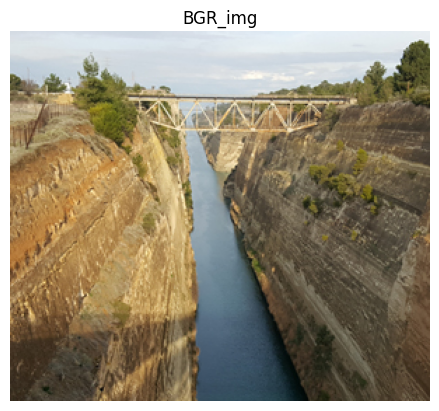

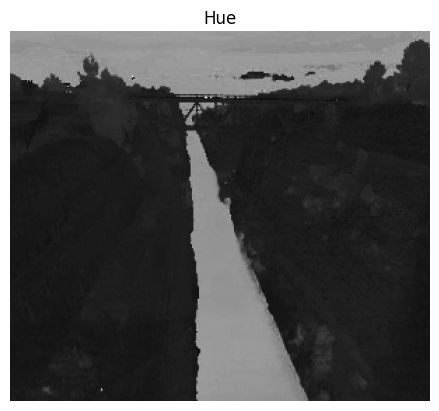

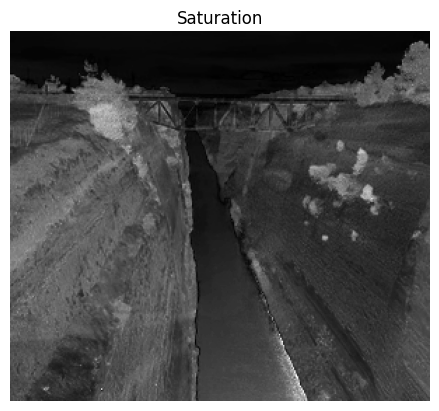

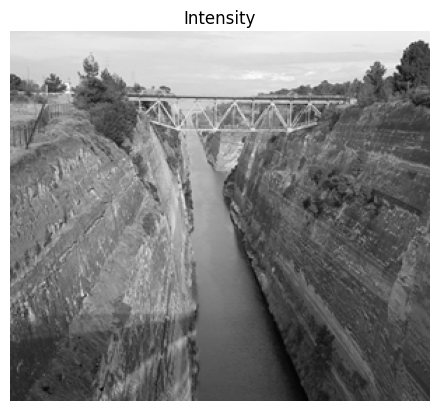

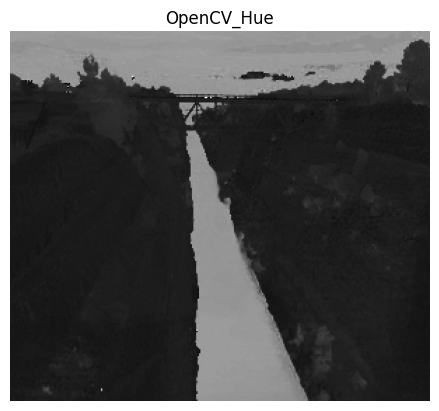

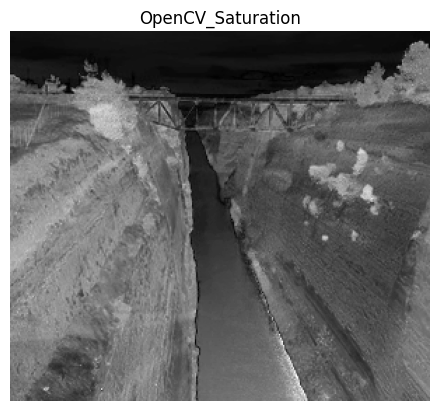

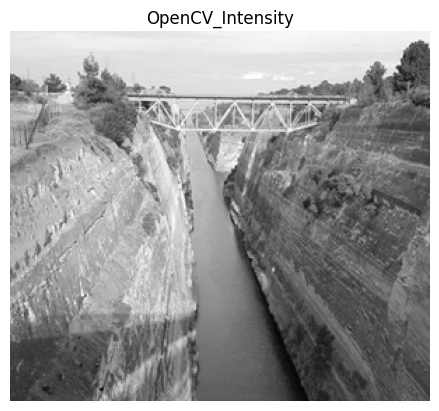

[None, None, None]

In [26]:
import numpy as np, cv2, math

def calc_hsi(bgr):
    # B, G, R = bgr.astype(float)                           # float 형 변환
    B, G, R = float(bgr[0]), float(bgr[1]), float(bgr[2])       # 속도면에 유리
    bgr_sum = (R + G + B)
    # 색상 계산
    tmp1 = ((R - G) + (R - B)) * 0.5
    tmp2 = math.sqrt((R - G) * (R - G) + (R - B) * (G - B))
    angle = math.acos(tmp1 / tmp2) * (180 / np.pi) if tmp2 else 0

    H = angle if B <= G else 360 - angle
    S = 1.0 - 3 * min([R, G, B]) / bgr_sum if bgr_sum else 0
    I = bgr_sum / 3                                                # 명도 계산
    return (H/2, S*255, I)

# BGR 컬러 -> HSI 컬러
def bgr2hsi(image):
    hsv = [[calc_hsi(pixel) for pixel in row] for row in image ]   # 2차원 배열 순회
    return (np.array(hsv)).astype('uint8')

BGR_img = cv2.imread(url + "images/color_space.jpg", cv2.IMREAD_COLOR) # 컬러 영상 읽기
if BGR_img is None: raise Exception("영상 파일 읽기 오류")

HSI_img = bgr2hsi(BGR_img)                  # BGR를 HSI로 변환
HSV_img = cv2.cvtColor(BGR_img, cv2.COLOR_BGR2HSV) # OpenCV 함수
Hue, Saturation, Intensity = cv2.split(HSI_img)                    # 채널 분리
Hue2, Saturation2, Intensity2 = cv2.split(HSV_img) 					# 채널 분리

titles = ['BGR_img','Hue','Saturation','Intensity']
[cv2_imshow(t, eval(t)) for t in titles]
[cv2_imshow('OpenCV_'+t, eval(t+'2')) for t in titles[1:]]	# OpenCV 결과 영상 표시

## 기타 컬러 공간


In [27]:
import cv2

BGR_img = cv2.imread(url + "images/color_space.jpg", cv2.IMREAD_COLOR) # 컬러 영상 읽기
if BGR_img is None: raise Exception("영상 파일 읽기 오류")

Gray_img = cv2.cvtColor(BGR_img, cv2.COLOR_BGR2GRAY) # 명암도 영상 변환
YCC_img = cv2.cvtColor(BGR_img, cv2.COLOR_BGR2YCrCb) # YCbCr 컬러 공간 변환
YUV_img = cv2.cvtColor(BGR_img, cv2.COLOR_BGR2YUV)   # YUV 컬러 공간 변환
LAB_img = cv2.cvtColor(BGR_img, cv2.COLOR_BGR2LAB)   # La*b* 컬러 공간 변환

YCC_ch = cv2.split(YCC_img)
YUV_ch = cv2.split(YUV_img)
Lab_ch = cv2.split(LAB_img)

cv2_imshow("BGR_img", BGR_img)
cv2_imshow("Gray_img", Gray_img)

sp1, sp2, sp3 = ['Y', 'Cr', 'Cb'] , ['Y', 'U', 'V'], ['L', 'A', 'B']
for i in range(len(sp1)):
    cv2_imshow("YCC_img[%d]-%s" %(i, sp1[i]), YCC_ch[i])
    cv2_imshow("YUV_img[%d]-%s" %(i, sp2[i]), YUV_ch[i])
    cv2_imshow("LAB_img[%d]-%s" %(i, sp3[i]), Lab_ch[i])

Output hidden; open in https://colab.research.google.com to view.

# Video 처리

In [ ]:
import cv2

# Open a video capture object
cap = cv2.VideoCapture("Your video's path.mp4")

# To check if the video has opened successfully of not
if not cap.isOpened():
    print("Error: Could not open the video.")
    exit()

# Loop through the video frames
while True:
    # Reading a frame from the video
    ret, frame = cap.read()

    # Break the loop if the video has ended
    if not ret:
        break

    # Display the original frame
    cv2.imshow('Original Video', frame)

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    cv2.imshow('Black and White Video', gray_frame)

    # Perform edge detection on the video
    edges_frame = cv2.Canny(gray_frame, 50, 150)
    cv2.imshow('Edges Video', edges_frame)

    # Break the loop if 'q' key is pressed
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

# Release the video capture object and close all windows
cap.release()
cv2.destroyAllWindows()

Error: Could not open the video.
